# Final Model Evaluation

This notebook fits the final models on 2021-22 through 2023-24 and evaluates them on the 2024-25 season. All settings were chosen before viewing the final results.

## Final model settings

- Context CatBoost: depth 5 and 1,200 iterations.
- Identity CatBoost: depth 5 and 612 iterations.
- History-aware rule: use player/team identity only when the player has at least 250 attempts in the development data; otherwise use the context prediction.
- No post-model calibration because temporal Platt scaling did not improve the development validation results.

The 2024-25 results are used only for final evaluation, not additional tuning.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.diagnostics import player_volume_groups, segment_metrics
from src.features import build_features, extract_target
from src.final_workflow import (
    FINAL_CONTEXT_ITERATIONS,
    FINAL_DEPTH,
    FINAL_IDENTITY_ITERATIONS,
    MINIMUM_IDENTITY_HISTORY,
    fit_final_models,
    predict_final_probabilities,
    validate_shot_frame,
)
from src.modeling import (
    calibration_table,
    constant_probability,
    evaluate_probabilities,
    make_logistic_pipeline,
)

pd.set_option('display.float_format', lambda value: f'{value:,.5f}')
sns.set_theme(style='whitegrid')

LOCKED_SETTINGS = {
    'depth': FINAL_DEPTH,
    'context_iterations': FINAL_CONTEXT_ITERATIONS,
    'identity_iterations': FINAL_IDENTITY_ITERATIONS,
    'minimum_identity_history': MINIMUM_IDENTITY_HISTORY,
}
LOCKED_SETTINGS

{'depth': 5,
 'context_iterations': 1200,
 'identity_iterations': 612,
 'minimum_identity_history': 250}

## 1. Load and check the data

The development seasons are combined for final fitting. The 2024-25 rows stay in their original order so saved probabilities can be joined back to the exact game events.

In [2]:
season_paths = {
    '2021-22': PROJECT_ROOT / 'data' / 'raw' / '2021.parquet',
    '2022-23': PROJECT_ROOT / 'data' / 'raw' / '2022.parquet',
    '2023-24': PROJECT_ROOT / 'data' / 'raw' / '2023.parquet',
    '2024-25': PROJECT_ROOT / 'data' / 'raw' / '2024.parquet',
}
missing_files = [str(path) for path in season_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f'Missing raw data files: {missing_files}')

raw_by_season = {label: pd.read_parquet(path) for label, path in season_paths.items()}
reference_columns = raw_by_season['2021-22'].columns.tolist()
for label, frame in raw_by_season.items():
    assert frame.columns.tolist() == reference_columns, f'Schema mismatch in {label}'
    validate_shot_frame(frame, require_target=(label != '2024-25'))

development_shots = pd.concat(
    [raw_by_season[label] for label in ['2021-22', '2022-23', '2023-24']],
    ignore_index=True,
)
holdout_shots = raw_by_season['2024-25'].reset_index(drop=True)

assert len(development_shots) == 652_641
assert len(holdout_shots) == 219_527
development_keys = pd.MultiIndex.from_frame(development_shots[['GAME_ID', 'GAME_EVENT_ID']])
holdout_keys = pd.MultiIndex.from_frame(holdout_shots[['GAME_ID', 'GAME_EVENT_ID']])
assert not development_keys.intersection(holdout_keys).size, 'Development and holdout events overlap'

pd.DataFrame(
    {'shots': {label: len(frame) for label, frame in raw_by_season.items()},
     'role': {
         '2021-22': 'development', '2022-23': 'development',
         '2023-24': 'development', '2024-25': 'final holdout',
     }}
)

,shots,role
2021-22,216722,development
2022-23,217218,development
2023-24,218701,development
2024-25,219527,final holdout


## 2. Fit the models and predict 2024-25 shots

Each model is fitted on all development data. The constant and logistic models are included as benchmarks.

In [3]:
development_target = extract_target(development_shots)
holdout_predictors = holdout_shots.drop(columns=['SHOT_MADE_FLAG', 'EVENT_TYPE'])
assert 'SHOT_MADE_FLAG' not in holdout_predictors and 'EVENT_TYPE' not in holdout_predictors

constant_predictions = constant_probability(development_target, len(holdout_predictors))
logistic_model = make_logistic_pipeline()
logistic_model.fit(build_features(development_shots), development_target)
logistic_predictions = logistic_model.predict_proba(build_features(holdout_predictors))[:, 1]

final_models = fit_final_models(development_shots)
final_predictions = predict_final_probabilities(
    final_models, development_shots, holdout_predictors
)

assert final_predictions.index.equals(holdout_shots.index)
assert len(final_predictions) == len(holdout_shots)
all_probability_columns = [
    'context_probability', 'identity_probability', 'history_aware_probability'
]
assert final_predictions[all_probability_columns].apply(lambda col: col.between(0, 1).all()).all()
assert np.isfinite(logistic_predictions).all() and np.isfinite(constant_predictions).all()

pd.Series({
    'development_shots': len(development_shots),
    'holdout_predictions': len(final_predictions),
    'players_using_identity': int(holdout_shots.loc[final_predictions['used_identity'], 'PLAYER_ID'].nunique()),
    'shots_using_identity': int(final_predictions['used_identity'].sum()),
    'shots_using_context_fallback': int((~final_predictions['used_identity']).sum()),
})

development_shots               652641
holdout_predictions             219527
players_using_identity             366
shots_using_identity            186174
shots_using_context_fallback     33353
dtype: int64

## 3. Evaluate the final season

Log loss is the primary metric. Brier score and ten-bin expected calibration error (ECE) provide additional checks of probability quality. Lower is better for all three.

In [4]:
holdout_target = extract_target(holdout_shots)
prediction_sets = {
    'Constant benchmark': constant_predictions,
    'Logistic regression': logistic_predictions,
    'CatBoost context': final_predictions['context_probability'].to_numpy(),
    'CatBoost identity': final_predictions['identity_probability'].to_numpy(),
    'CatBoost history-aware': final_predictions['history_aware_probability'].to_numpy(),
}
holdout_metrics = pd.DataFrame(
    [
        {'model': model_name, **evaluate_probabilities(holdout_target, probabilities)}
        for model_name, probabilities in prediction_sets.items()
    ]
).sort_values('log_loss').reset_index(drop=True)
holdout_metrics

,model,log_loss,brier_score,ece
0,CatBoost identity,0.63401,0.22283,0.01027
1,CatBoost history-aware,0.63419,0.22291,0.00457
2,CatBoost context,0.63586,0.22366,0.00368
3,Logistic regression,0.64037,0.22556,0.00724
4,Constant benchmark,0.69101,0.24893,0.00307


In [5]:
logistic_log_loss = holdout_metrics.loc[
    holdout_metrics['model'] == 'Logistic regression', 'log_loss'
].iloc[0]
final_log_loss = holdout_metrics.loc[
    holdout_metrics['model'] == 'CatBoost history-aware', 'log_loss'
].iloc[0]
identity_log_loss = holdout_metrics.loc[
    holdout_metrics['model'] == 'CatBoost identity', 'log_loss'
].iloc[0]

pd.Series({
    'history_aware_log_loss': final_log_loss,
    'improvement_over_logistic': logistic_log_loss - final_log_loss,
    'relative_improvement_over_logistic_percent': 100 * (logistic_log_loss - final_log_loss) / logistic_log_loss,
    'improvement_over_raw_identity': identity_log_loss - final_log_loss,
})

history_aware_log_loss                        0.63419
improvement_over_logistic                     0.00618
relative_improvement_over_logistic_percent    0.96508
improvement_over_raw_identity                -0.00018
dtype: float64

## 4. Calibration and player-history results

The calibration curve compares predicted probability with observed make rate. The player-history table compares performance for players with different amounts of prior data.

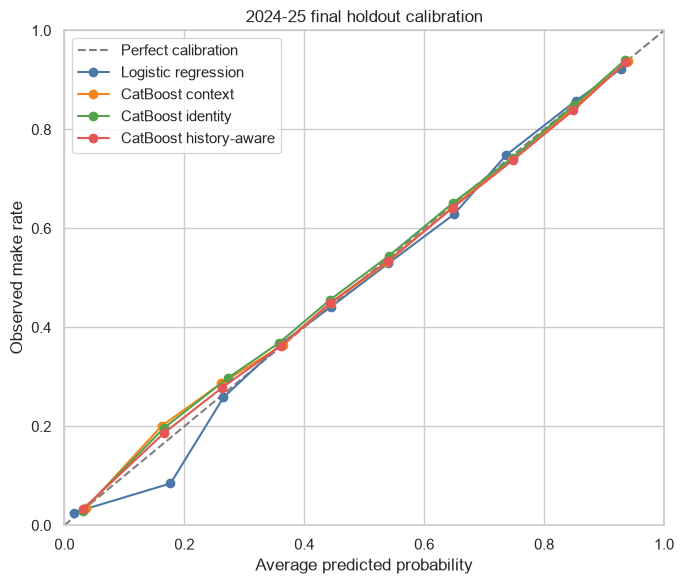

In [6]:
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
for model_name, color in [
    ('Logistic regression', '#4c78a8'),
    ('CatBoost context', '#f58518'),
    ('CatBoost identity', '#54a24b'),
    ('CatBoost history-aware', '#e45756'),
]:
    table = calibration_table(holdout_target, prediction_sets[model_name]).query('shots > 0')
    plt.plot(
        table['average_prediction'], table['observed_make_rate'],
        marker='o', label=model_name, color=color,
    )
plt.xlabel('Average predicted probability')
plt.ylabel('Observed make rate')
plt.title('2024-25 final holdout calibration')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
volume_groups = player_volume_groups(development_shots, holdout_shots)
volume_records = []
for model_name in ['CatBoost context', 'CatBoost identity', 'CatBoost history-aware']:
    summary = segment_metrics(
        holdout_target, prediction_sets[model_name], volume_groups
    )
    summary['model'] = model_name
    volume_records.append(summary)
player_volume_results = pd.concat(volume_records, ignore_index=True)
player_volume_results.pivot(
    index=['segment', 'shots'], columns='model', values='log_loss'
).reset_index()

model,segment,shots,CatBoost context,CatBoost history-aware,CatBoost identity
0,Unseen,18677,0.62684,0.62684,0.62550
1,1-249,14676,0.63034,0.63034,0.62937
2,250-749,25073,0.62545,0.62315,0.62315
3,750+,161101,0.63903,0.63711,0.63711


## Final result interpretation

The locked history-aware CatBoost model achieved **0.63419 log loss**, **0.22291 Brier score**, and **0.00457 ECE** on 219,527 shots from 2024-25. It improved log loss by 0.00618 (0.97%) over logistic regression and by 0.00167 over context-only CatBoost.

Raw identity CatBoost produced the lowest holdout log loss at 0.63401, beating the history-aware rule by 0.00018. However, its ECE was 0.01027 compared with 0.00457 for the history-aware model. The rule therefore gave up a very small amount of discrimination while more than halving the calibration error. Because the history rule was selected before the holdout was opened, it remains the project's final model.

Raw identity helped unseen and 1-249-attempt players in 2024-25 even though it had hurt those groups during development. This shows that the value of player identity can change across seasons.

## 5. Save outputs

Save the fitted models, predictions, and metrics so the report figures can be recreated without refitting the models.

In [8]:
models_dir = PROJECT_ROOT / 'models'
outputs_dir = PROJECT_ROOT / 'outputs'
models_dir.mkdir(exist_ok=True)
outputs_dir.mkdir(exist_ok=True)

final_models.context.save_model(models_dir / 'context_catboost.cbm')
final_models.identity.save_model(models_dir / 'identity_catboost.cbm')

saved_predictions = holdout_shots[['GAME_ID', 'GAME_EVENT_ID']].copy()
saved_predictions = pd.concat([saved_predictions, final_predictions], axis=1)
saved_predictions.to_parquet(outputs_dir / 'final_holdout_predictions.parquet', index=False)

metrics_payload = {
    'holdout_season': '2024-25',
    'holdout_opened_once': True,
    'locked_settings': LOCKED_SETTINGS,
    'metrics': holdout_metrics.to_dict(orient='records'),
}
with (outputs_dir / 'final_holdout_metrics.json').open('w', encoding='utf-8') as output_file:
    json.dump(metrics_payload, output_file, indent=2)

pd.Series({
    'context_model': str((models_dir / 'context_catboost.cbm').relative_to(PROJECT_ROOT)),
    'identity_model': str((models_dir / 'identity_catboost.cbm').relative_to(PROJECT_ROOT)),
    'predictions': str((outputs_dir / 'final_holdout_predictions.parquet').relative_to(PROJECT_ROOT)),
    'metrics': str((outputs_dir / 'final_holdout_metrics.json').relative_to(PROJECT_ROOT)),
})

context_model                  models\context_catboost.cbm
identity_model                models\identity_catboost.cbm
predictions       outputs\final_holdout_predictions.parquet
metrics                  outputs\final_holdout_metrics.json
dtype: object